In [97]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 51.406696,
	"longitude": -0.288789,
	"start_date": "2025-04-21",
	"end_date": "2025-04-21",
	"hourly": "temperature_2m",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	)
}

hourly_data["temperature_2m"] = hourly_temperature_2m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)


Coordinates: 51.42354965209961°N -0.325469970703125°E
Elevation: 13.0 m asl
Timezone difference to GMT+0: 0s

Hourly data
                         date  temperature_2m
0  2025-04-21 00:00:00+00:00        9.750000
1  2025-04-21 01:00:00+00:00        9.950000
2  2025-04-21 02:00:00+00:00        9.850000
3  2025-04-21 03:00:00+00:00        9.900000
4  2025-04-21 04:00:00+00:00       10.000000
5  2025-04-21 05:00:00+00:00       10.000000
6  2025-04-21 06:00:00+00:00       10.050000
7  2025-04-21 07:00:00+00:00       10.300000
8  2025-04-21 08:00:00+00:00       11.050000
9  2025-04-21 09:00:00+00:00       12.350000
10 2025-04-21 10:00:00+00:00       13.850000
11 2025-04-21 11:00:00+00:00       15.100000
12 2025-04-21 12:00:00+00:00       15.950000
13 2025-04-21 13:00:00+00:00       16.100000
14 2025-04-21 14:00:00+00:00       16.950001
15 2025-04-21 15:00:00+00:00       12.800000
16 2025-04-21 16:00:00+00:00       12.650000
17 2025-04-21 17:00:00+00:00       13.400000
18 2025-04-21 18:00:00

In [98]:
print(hourly_temperature_2m)

[ 9.75  9.95  9.85  9.9  10.   10.   10.05 10.3  11.05 12.35 13.85 15.1
 15.95 16.1  16.95 12.8  12.65 13.4  13.55 12.65 11.65 10.9  10.1   9.3 ]


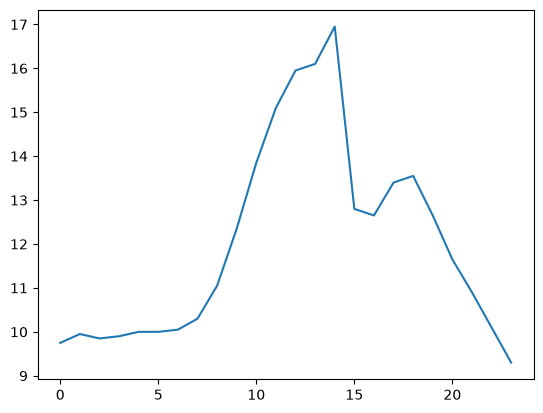

In [99]:
import matplotlib.pyplot as plt
hours = list(range(0,24))
temps = hourly_temperature_2m
plt.plot(hours,temps)
plt.show()

In [100]:
print(hours)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


dT/dt = -k(T - Ta)

In [ ]:
import pandas as pd 
df = pd.read_csv(
    "1644725-temp.csv",
    header=None,
    names=["timestamp", "indoor_temp"])

df["time"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
hourly_indoor = (
    df.set_index("time")["indoor_temp"]
      .resample("1h")
      .mean())
print(hourly_indoor)


time
2024-12-10 12:00:00+00:00    17.523333
2024-12-10 13:00:00+00:00    17.602605
2024-12-10 14:00:00+00:00    17.622437
2024-12-10 15:00:00+00:00    17.702250
2024-12-10 16:00:00+00:00    17.844118
                               ...    
2025-12-05 19:00:00+00:00    17.157563
2025-12-05 20:00:00+00:00    17.260840
2025-12-05 21:00:00+00:00    17.318750
2025-12-05 22:00:00+00:00    17.313583
2025-12-05 23:00:00+00:00    17.256639
Freq: h, Name: indoor_temp, Length: 8652, dtype: float64


In [102]:
day = "2025-04-21"

indoor_day = hourly_indoor.loc[day]

#print(indoor_day)
#print(len(indoor_day))
#print(df["indoor_temp"])
print(indoor_day.values)


[17.37827586 17.24066667 17.12714286 17.02341667 16.93706897 16.87109244
 16.82127119 16.83747899 16.97697479 16.88389831 16.85008403 16.95268908
 17.23058824 17.50641667 17.64949153 17.61487395 17.30117647 17.35184874
 17.46225    17.53449153 17.85533898 18.19825    18.35273504 18.24008333]


In [103]:
import numpy as np

in_vs_out = pd.DataFrame({
    "indoor": indoor_day.to_numpy(),
    "outdoor": hourly_data["temperature_2m"]
}, index=indoor_day.index)

in_vs_out["indoor"] = pd.to_numeric(in_vs_out["indoor"])
in_vs_out["outdoor"] = pd.to_numeric(in_vs_out["outdoor"])

in_vs_out["indoor_next"] = in_vs_out["indoor"].shift(-1)

in_vs_out["k"] = -np.log((in_vs_out["indoor_next"] - in_vs_out["outdoor"]) / (in_vs_out["indoor"] - in_vs_out["outdoor"]))  # finding k by rearranging formula to -1/deltat(next temp - out temp) / (indoor temp - outdoor temp)

print(in_vs_out)

                              indoor    outdoor  indoor_next         k
time                                                                  
2025-04-21 00:00:00+01:00  17.378276   9.750000    17.240667  0.018204
2025-04-21 01:00:00+01:00  17.240667   9.950000    17.127143  0.015694
2025-04-21 02:00:00+01:00  17.127143   9.850000    17.023417  0.014356
2025-04-21 03:00:00+01:00  17.023417   9.900000    16.937069  0.012196
2025-04-21 04:00:00+01:00  16.937069  10.000000    16.871092  0.009556
2025-04-21 05:00:00+01:00  16.871092  10.000000    16.821271  0.007277
2025-04-21 06:00:00+01:00  16.821271  10.050000    16.837479 -0.002391
2025-04-21 07:00:00+01:00  16.837479  10.300000    16.976975 -0.021113
2025-04-21 08:00:00+01:00  16.976975  11.050000    16.883898  0.015828
2025-04-21 09:00:00+01:00  16.883898  12.350000    16.850084  0.007486
2025-04-21 10:00:00+01:00  16.850084  13.850000    16.952689 -0.033629
2025-04-21 11:00:00+01:00  16.952689  15.100000    17.230588 -0.139760
2025-0

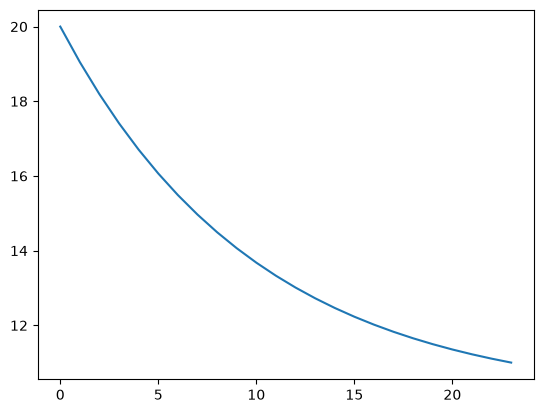

[20.0, 19.048374180359595, 18.18730753077982, 17.40818220681718, 16.703200460356392, 16.065306597126334, 15.488116360940264, 14.965853037914094, 14.493289641172215, 14.065696597405992, 13.678794411714424, 13.328710836980795, 13.011942119122022, 12.725317930340125, 12.465969639416064, 12.231301601484299, 12.018965179946555, 11.826835240527346, 11.652988882215865, 11.495686192226351, 11.353352832366127, 11.224564282529819, 11.108031583623339, 11.002588437228038]


In [104]:
import matplotlib.pyplot as plt
import numpy as np
import math

T0 = 20
Tout = 10
k = 0.1
dt = 1
hours = 24
# T(t) = Tout + (T0 - Tout)*e^(-kt)

#Tout + (T0 - Tout)*math.e**(-k*t)
times = []
temps = []

for t in range(0,hours):
    temp = Tout + (T0 - Tout)*math.e**(-k*t)
    times.append(t)
    temps.append(temp)

plt.plot(times,temps)
plt.show()

print(temps)

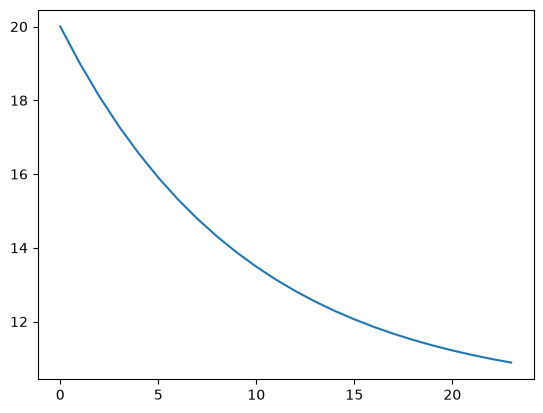

In [105]:
T0 = 20
Tout = 10
k = 0.1
dt = 1
hours = 24
times = []
temps2 = [T0]
for t in range(0,hours):
    times.append(t)
    T = temps2[t]
    newtemp = T + (dt*(-1*k*((T - Tout))))
    temps2.append(newtemp)

temps2.pop()
plt.plot(times,temps2)
plt.show()

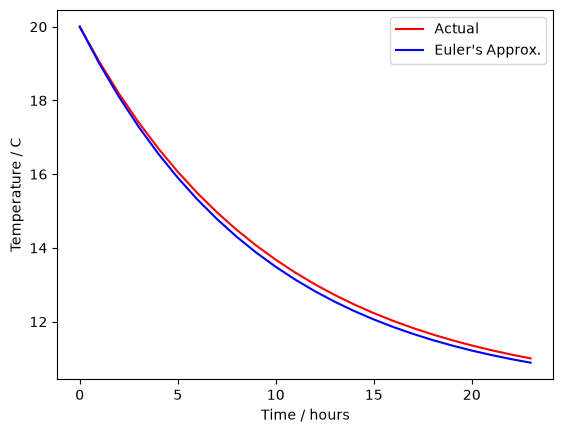

In [106]:
import matplotlib.pyplot as plt
plt.plot(times,temps,label = "Actual", color = "red")
plt.plot(times,temps2,label = "Euler's Approx.", color = "blue")

plt.xlabel("Time / hours")
plt.ylabel("Temperature / C")

plt.legend()
plt.show()

In [107]:
max = 0
for x in range(len(temps)):
    if temps[x] - temps2[x] > max:
        max = temps[x] - temps2[x]
print(max)

0.19201001071442292


In [108]:
on_or_off = [1,0,0,1,0,1,0,0,0,1,1,1,0,1,1,1,0,0,1,1,0,1,0,1]
h = 2
T0 = 20
Tout = 10
k = 0.1
dt = 1
hours = 24
times = []
temps2 = [T0]
for t in range(0,hours):
    times.append(t)
    T = temps2[t]
    newtemp = (T + (dt*(-1*k*((T - Tout))))) + (h*(on_or_off[t]))
    temps2.append(newtemp)

print(temps2)

[20, 21.0, 19.9, 18.91, 20.019, 19.0171, 20.115389999999998, 19.103851, 18.1934659, 17.37411931, 18.636707379, 19.7730366411, 20.79573297699, 19.716159679291, 20.7445437113619, 21.670089340225708, 22.503080406203136, 21.25277236558282, 20.12749512902454, 21.114745616122086, 22.003271054509877, 20.80294394905889, 21.722649554153, 20.5503845987377, 21.49534613886393]


In [109]:
on_or_off = [1,0,0,1,0,1,0,0,0,1,1,1,0,1,1,1,0,0,1,1,0,1,0,1]
h = 2
T0 = 20
Tout = hourly_temperature_2m
k = 0.1
dt = 1
hours = 24
times = []
temps2 = [T0]
for t in range(0,hours):
    times.append(t)
    T = temps2[t]
    newtemp = (T + (dt*(-1*k*((T - Tout[t]))))) + (h*(on_or_off[t]))
    temps2.append(newtemp)

print(temps2)



[20, np.float32(20.975), np.float32(19.8725), np.float32(18.870249), np.float32(19.973225), np.float32(18.975903), np.float32(20.078312), np.float32(19.075481), np.float32(18.197933), np.float32(17.483139), np.float32(18.969826), np.float32(20.457844), np.float32(21.92206), np.float32(21.324854), np.float32(22.802368), np.float32(24.21713), np.float32(25.075418), np.float32(23.832876), np.float32(22.789589), np.float32(23.86563), np.float32(24.744066), np.float32(23.43466), np.float32(24.181194), np.float32(22.773075), np.float32(23.425768)]


In [110]:

h = 2
T0 = 11 # avg annual temp in Kingston
Tout = hourly_temperature_2m
H = 0
k = 0.1
dt = 1
hours = 24
times = []
temps2 = [T0]
for t in range(0,hours):
    times.append(t)
    T = temps2[t]
    pure_indoor = (T + (dt*(-1*k*((T - Tout[t])))))
    if pure_indoor <= 18:
        H = 1
    else:
        H = 0
    newtemp = pure_indoor + (h*H))
    print(pure_indoor)
    print(H)
    temps2.append(newtemp)

print(temps2)

SyntaxError: unmatched ')' (653971926.py, line 18)

In [ ]:
occupied = [1,0,0,1,0,1,0,0,0,1,1,1,0,1,1,1,0,0,1,1,0,1,0,1]
comfort = []
for i in occupied:
    if occupied[i] == 0:
        comfort.append(14)
    if occupied[i] ==1:
        comfort.append(18)

h = 2
T0 = 11 # avg annual temp in Kingston
Tout = hourly_temperature_2m
H = []
k = 0.1
dt = 1
hours = 24
times = []
temps3 = [T0]

for t in range(0,hours):
    times.append(t)
    T = temps3[t]
    pure_indoor = (T + (dt*(-1*k*((T - Tout[t])))))
    if pure_indoor <= comfort[t]:
        H = 1
        H.append(1)
    else:
        H = 0
        H.append(0)
    newtemp = pure_indoor + (h*H)
    print(pure_indoor)
    print(H)
    temps3.append(newtemp)

print(temps3)

10.875
1
12.5825
1
14.10925
1
15.488324
0
14.939491
1
16.245543
0
15.625988
1
16.893389
1
18.10905
0
17.533146
0
17.164831
0
16.958347
0
16.857513
1
18.581762
0
18.418587
0
17.856728
0
17.336056
1
18.74245
0
18.223206
0
17.665886
0
17.064297
1
18.247868
0
17.43308
1
18.419773
0
[11, np.float32(12.875), np.float32(14.5825), np.float32(16.10925), np.float32(15.488324), np.float32(16.939491), np.float32(16.245543), np.float32(17.625988), np.float32(18.893389), np.float32(18.10905), np.float32(17.533146), np.float32(17.164831), np.float32(16.958347), np.float32(18.857513), np.float32(18.581762), np.float32(18.418587), np.float32(17.856728), np.float32(19.336056), np.float32(18.74245), np.float32(18.223206), np.float32(17.665886), np.float32(19.064297), np.float32(18.247868), np.float32(19.43308), np.float32(18.419773)]


In [ ]:
occupied = [1,0,0,1,0,1,0,0,0,1,1,1,0,1,1,1,0,0,1,1,0,1,0,1]
comfort = []
for i in occupied:
    if occupied[i] == 0:
        comfort.append(14)
    if occupied[i] ==1:
        comfort.append(18)

error = []
for y in range(len(temps)):
    error_at_time = temps[y] - temps2[y]
    error.append(error_at_time)
 
h = 2
T0 = 11 # avg annual temp in Kingston
Tout = hourly_temperature_2m
H_at_time = []
k = 0.1
dt = 1
hours = 24
times = []
temps3 = [T0]
for t in range(0,hours):
    times.append(t)
    T = temps3[t]
    pure_indoor = (T + (dt*(-1*k*((T - Tout[t]))))) + error[t]
    if pure_indoor <= comfort[t]:
        H = 1
        H_at_time.append(1)
    else:
        H = 0
        H_at_time.append(0)
    newtemp = pure_indoor + (h*H) + error[t]
    print(pure_indoor)
    print(H)
    temps3.append(newtemp)

print(temps3)

10.875
1
12.630875
1
14.283632
1
15.842028
0
15.50639
1
17.044138
0
16.662796
1
18.165735
0
17.807375
1
19.422886
0
19.229952
0
19.180372
0
19.216526
0
19.257208
0
19.369886
0
19.04575
0
18.72727
0
18.50301
0
18.302956
0
18.019333
0
17.650337
1
19.029507
0
18.377153
0
17.696667
0
[11, np.float32(12.875), np.float32(14.679249), np.float32(16.37094), np.float32(15.96021), np.float32(17.64859), np.float32(17.204544), np.float32(18.836502), np.float32(18.34862), np.float32(19.995993), np.float32(19.614378), np.float32(19.421963), np.float32(19.370977), np.float32(19.404173), np.float32(19.44066), np.float32(19.548178), np.float32(19.21814), np.float32(18.893215), np.float32(18.662127), np.float32(18.454998), np.float32(18.164167), np.float32(19.787924), np.float32(19.159882), np.float32(18.500414), np.float32(17.812962)]


In [ ]:
print(in_vs_out["indoor"].keys
      )

<bound method Series.keys of time
2025-04-21 00:00:00+01:00    17.378276
2025-04-21 01:00:00+01:00    17.240667
2025-04-21 02:00:00+01:00    17.127143
2025-04-21 03:00:00+01:00    17.023417
2025-04-21 04:00:00+01:00    16.937069
2025-04-21 05:00:00+01:00    16.871092
2025-04-21 06:00:00+01:00    16.821271
2025-04-21 07:00:00+01:00    16.837479
2025-04-21 08:00:00+01:00    16.976975
2025-04-21 09:00:00+01:00    16.883898
2025-04-21 10:00:00+01:00    16.850084
2025-04-21 11:00:00+01:00    16.952689
2025-04-21 12:00:00+01:00    17.230588
2025-04-21 13:00:00+01:00    17.506417
2025-04-21 14:00:00+01:00    17.649492
2025-04-21 15:00:00+01:00    17.614874
2025-04-21 16:00:00+01:00    17.301176
2025-04-21 17:00:00+01:00    17.351849
2025-04-21 18:00:00+01:00    17.462250
2025-04-21 19:00:00+01:00    17.534492
2025-04-21 20:00:00+01:00    17.855339
2025-04-21 21:00:00+01:00    18.198250
2025-04-21 22:00:00+01:00    18.352735
2025-04-21 23:00:00+01:00    18.240083
Freq: h, Name: indoor, dtype: 

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np 
model = LinearRegression()
x = []
y = []
dt = 1
print(len(indoor_day.values))
print(len(hourly_temperature_2m))
for j in range(len(indoor_day)-1):
    x.append(indoor_day.values[j] - hourly_temperature_2m[j])
    next_indoor = indoor_day.values[j+1]
    y.append((next_indoor - indoor_day.values[j])/dt)
    print(x,y)
print(len(x),len(y))
model.fit(
    np.array(x).reshape(-1,1),
    y
)

k = -model.coef_[0]

print("Estimated k:", k)


24
24
[np.float64(7.628275862068964)] [np.float64(-0.1376091954022982)]
[np.float64(7.628275862068964), np.float64(7.290666857401529)] [np.float64(-0.1376091954022982), np.float64(-0.1135238095238087)]
[np.float64(7.628275862068964), np.float64(7.290666857401529), np.float64(7.277142475673131)] [np.float64(-0.1376091954022982), np.float64(-0.1135238095238087), np.float64(-0.10372619047619125)]
[np.float64(7.628275862068964), np.float64(7.290666857401529), np.float64(7.277142475673131), np.float64(7.1234170481363925)] [np.float64(-0.1376091954022982), np.float64(-0.1135238095238087), np.float64(-0.10372619047619125), np.float64(-0.0863477011494247)]
[np.float64(7.628275862068964), np.float64(7.290666857401529), np.float64(7.277142475673131), np.float64(7.1234170481363925), np.float64(6.937068965517241)] [np.float64(-0.1376091954022982), np.float64(-0.1135238095238087), np.float64(-0.10372619047619125), np.float64(-0.0863477011494247), np.float64(-0.06597652854244984)]
[np.float64(7.6282

In [ ]:
occupied = [1,0,0,1,0,1,0,0,0,1,1,1,0,1,1,1,0,0,1,1,0,1,0,1]
comfort = []
for i in occupied:
    if i == 0:
        comfort.append(14)
    if i ==1:
        comfort.append(18)

error = []
for y in range(len(temps)):
    error_at_time = temps[y] - temps2[y]
    error.append(error_at_time)
 
h = 2
T0 = 11 # avg annual temp in Kingston
Tout = hourly_temperature_2m
H_at_time = []


from sklearn.linear_model import LinearRegression
import numpy as np 
model = LinearRegression()
x = []
y = []
dt = 1
print(len(indoor_day.values))
print(len(hourly_temperature_2m))
for j in range(len(indoor_day)-1):
    x.append(indoor_day.values[j] - hourly_temperature_2m[j])
    next_indoor = indoor_day.values[j+1]
    y.append((next_indoor - indoor_day.values[j])/dt)
    print(x,y)
print(len(x),len(y))
model.fit(
    np.array(x).reshape(-1,1),
    y)

k = -model.coef_[0]

dt = 1
hours = 24
times = []
temps3 = [T0]
for t in range(0,hours):
    times.append(t)
    T = temps3[t]
    pure_indoor = (T + (dt*(-1*k*((T - Tout[t]))))) + error[t]
    if pure_indoor <= comfort[t]:
        H = 1
        H_at_time.append(1)
    else:
        H = 0
        H_at_time.append(0)
    newtemp = pure_indoor + (h*H) + error[t]
    print(pure_indoor)
    print(H)
    temps3.append(newtemp)

print(temps3)
print(H_at_time)

24
24
[np.float64(7.628275862068964)] [np.float64(-0.1376091954022982)]
[np.float64(7.628275862068964), np.float64(7.290666857401529)] [np.float64(-0.1376091954022982), np.float64(-0.1135238095238087)]
[np.float64(7.628275862068964), np.float64(7.290666857401529), np.float64(7.277142475673131)] [np.float64(-0.1376091954022982), np.float64(-0.1135238095238087), np.float64(-0.10372619047619125)]
[np.float64(7.628275862068964), np.float64(7.290666857401529), np.float64(7.277142475673131), np.float64(7.1234170481363925)] [np.float64(-0.1376091954022982), np.float64(-0.1135238095238087), np.float64(-0.10372619047619125), np.float64(-0.0863477011494247)]
[np.float64(7.628275862068964), np.float64(7.290666857401529), np.float64(7.277142475673131), np.float64(7.1234170481363925), np.float64(6.937068965517241)] [np.float64(-0.1376091954022982), np.float64(-0.1135238095238087), np.float64(-0.10372619047619125), np.float64(-0.0863477011494247), np.float64(-0.06597652854244984)]
[np.float64(7.6282

In [ ]:
#import pandas as pd

#carbon_intensity  = pd.read_csv("regional_carbon_intensity.csv")

#print(carbon_intensity.columns)
#print(carbon_intensity.head())

Index(['datetime', 'North Scotland', 'South Scotland', 'North West England',
       'North East England', 'Yorkshire', 'North Wales and Merseyside',
       'South Wales', 'West Midlands', 'East Midlands', 'East England',
       'South West England', 'South England', 'London', 'South East England'],
      dtype='str')
              datetime  North Scotland  South Scotland  North West England  \
0  2018-09-17T23:00:00            30.0            11.0                38.0   
1  2018-09-17T23:30:00            44.0             7.0                41.0   
2  2018-09-18T00:00:00            44.0             8.0                39.0   
3  2018-09-18T00:30:00            44.0            11.0                37.0   
4  2018-09-18T01:00:00            45.0            13.0                34.0   

   North East England  Yorkshire  North Wales and Merseyside  South Wales  \
0                24.0      319.0                       157.0        271.0   
1                30.0      298.0                       183

In [117]:
carbon_intensity = pd.read_csv("regional_carbon_intensity.csv")

carbon_intensity["datetime"] = pd.to_datetime(carbon_intensity["datetime"])

london = carbon_intensity[["datetime", "London"]]

print(london.tail())

carbon_intensity["datetime"] = pd.to_datetime(carbon_intensity["datetime"])

carbon_hourly = (carbon_intensity.set_index("datetime")["London"].resample("1h").mean())

last24_carbon_hourly = carbon_hourly.tail(24).tolist()

                  datetime  London
136185 2026-07-24 10:00:00   101.0
136186 2026-07-24 10:30:00    98.0
136187 2026-07-24 11:00:00    99.0
136188 2026-07-24 11:30:00    96.0
136189 2026-07-24 12:00:00    90.0


In [118]:
P = 2 # heater power in kW
dt = 1 # time in hours

energy_per_hour = []
carbon_per_hour = []

for i in range(24):
    energy = P*H_at_time[i]*dt
    carbon = energy*last24_carbon_hourly[i]

    energy_per_hour.append(energy)
    carbon_per_hour.append(carbon)

total_energy = sum(energy_per_hour)
total_carbon = sum(carbon_per_hour)

